## Module 1 Homework

In this homework, we're going to download finance data from various sources and make simple calculations/analysis.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
import matplotlib.pyplot as plt
#import plotly.graph_objs as go
#import plotly.express as px
#import matplotlib.ticker as mtick
#import time
import datetime

### Question 1: [Macro] Average growth of GDP in 2023

**What is the average growth (in %) of GDP in 2023?**

Download the timeseries Real Gross Domestic Product (GDPC1) from FRED (https://fred.stlouisfed.org/series/GDPC1). 
Calculate year-over-year (YoY) growth rate (that is, divide current value to one 4 quarters ago). Find the average YoY growth in 2023 (average from 4 YoY numbers).
Round to 1 digit after the decimal point: e.g. if you get 5.66% growth => you should answer  5.7

In [2]:
start_date = datetime.date(2022, 1, 1)
gdp = pdr.DataReader("GDPC1", "fred", start=start_date)
gdp

,GDPC1
DATE,
2022-01-01,21738.871
2022-04-01,21708.160
2022-07-01,21851.134
2022-10-01,21989.981
2023-01-01,22112.329
2023-04-01,22225.350
2023-07-01,22490.692
2023-10-01,22679.255


In [3]:
gdp["YoY Growth"] = gdp['GDPC1'].pct_change(periods=4) * 100

avg_growth_2023 = gdp['YoY Growth']['2023']#.mean()
avg_growth_2023

DATE
2023-01-01    1.717927
2023-04-01    2.382468
2023-07-01    2.926887
2023-10-01    3.134491
Name: YoY Growth, dtype: float64

In [4]:
gdp['YoY Growth']['2023'].mean()

2.5404433928676253

### Question 2. [Macro] Inverse "Treasury Yield"

**Find the min value of (dgs10-dgs2) after since year 2000 (2000-01-01) and write it down as an answer, round to 1 digit after the decimal point.**


Download DGS2 and DGS10 interest rates series (https://fred.stlouisfed.org/series/DGS2,
 https://fred.stlouisfed.org/series/DGS10). Join them together to one dataframe on date (you might need to read about pandas.DataFrame.join()), calculate the difference dgs10-dgs2 daily.

(Additional: think about what does the "inverted yield curve" mean for the market and investors? do you see the same thing in your country/market of interest? Do you think it can be a good predictive feature for the models?)

In [5]:
start_date = datetime.date(2000, 1, 1)
dgs2 = pdr.DataReader("DGS2", "fred", start=start_date)
dgs10 = pdr.DataReader("DGS10", "fred", start=start_date)
df = dgs2.join(dgs10)
df

,DGS2,DGS10
DATE,,
2000-01-03,6.38,6.58
2000-01-04,6.30,6.49
2000-01-05,6.38,6.62
2000-01-06,6.35,6.57
2000-01-07,6.31,6.52
...,...,...
2024-04-16,4.97,4.67
2024-04-17,4.93,4.59
2024-04-18,4.98,4.64


In [6]:
df['dgs10-dgs2'] = df["DGS10"] - df["DGS2"]

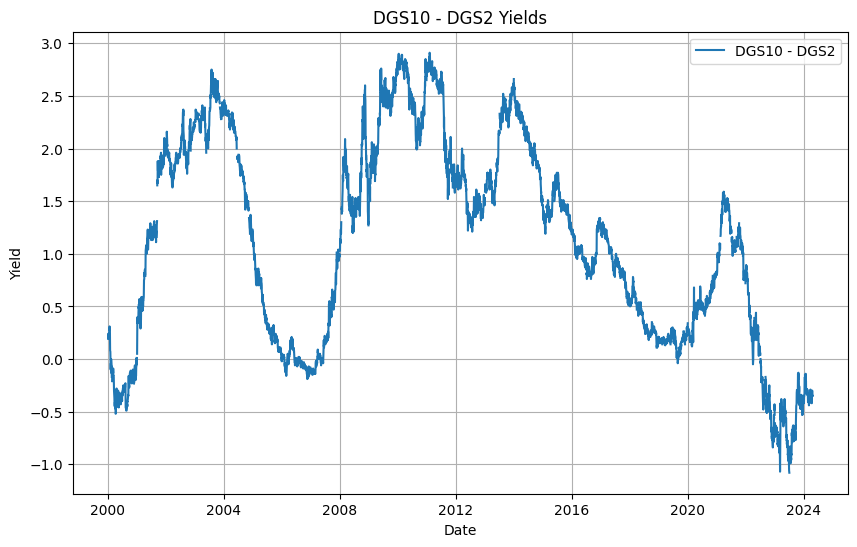

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['dgs10-dgs2'], label='DGS10 - DGS2')

plt.xlabel('Date')
plt.ylabel('Yield')
plt.title('DGS10 - DGS2 Yields')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
round((df['dgs10-dgs2']).min(),1)

-1.1

### Question 3. [Index] Which Index is better recently?

**Compare S&P 500 and IPC Mexico indexes by the 5 year growth and write down the largest value as an answer (%)**

Download on Yahoo Finance two daily index prices for S&P 500 (^GSPC, https://finance.yahoo.com/quote/%5EGSPC/) and IPC Mexico (^MXX, https://finance.yahoo.com/quote/%5EMXX/). Compare 5Y growth for both (between 2019-04-09 and 2024-04-09). Select the higher growing index and write down the growth in % (closest integer %). E.g. if ratio end/start was 2.0925 (or growth of 109.25%), you need to write down 109 as your answer.

(Additional: think of other indexes and try to download stats and compare the growth? Do create 10Y and 20Y growth stats. What is an average yearly growth rate (CAGR) for each of the indexes you select?)

In [9]:
sp500 = yf.download('^GSPC', start='2019-04-09', end='2024-04-09')['Adj Close']
ipc_mexico = yf.download('^MXX', start='2019-04-09', end='2024-04-09')['Adj Close']

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [10]:
sp500_growth = (sp500.iloc[-1] / sp500.iloc[0] - 1) * 100
ipc_mexico_growth = (ipc_mexico.iloc[-1] / ipc_mexico.iloc[0] - 1) * 100

In [11]:
if sp500_growth > ipc_mexico_growth:
    largest_growth = round(sp500_growth)
    index_name = "S&P 500"
else:
    largest_growth = round(ipc_mexico_growth)
    index_name = "IPC Mexico"

In [12]:
print(f"'{index_name}' - {largest_growth}%")

'S&P 500' - 81%


### Question 4. [Stocks OHLCV] 52-weeks range ratio (2023) for the selected stocks


**Find the largest range ratio [=(max-min)/max] of Adj.Close prices in 2023**


Download the 2023 daily OHLCV data on Yahoo Finance for top6 stocks on earnings (https://companiesmarketcap.com/most-profitable-companies/): 2222.SR,BRK-B, AAPL, MSFT, GOOG, JPM.

Here is the example data you should see in Pandas for "2222.SR": https://finance.yahoo.com/quote/2222.SR/history

Calculate maximum-minimim "Adj.Close" price for each stock and divide it by the maximum "Adj.Close" value.
Round the result to two decimal places (e.g. 0.1575 will be 0.16)

(Additional: why this may be important for your research?)

In [13]:
import yfinance as yf

stocks = ['2222.SR', 'BRK-B', 'AAPL', 'MSFT', 'GOOG', 'JPM']

stock_data = {}
for stock in stocks:
    stock_data[stock] = yf.download(stock, start='2023-01-01', end='2023-12-31')

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [14]:
max_range_ratio = 0
max_range_stock = None
for stock, data in stock_data.items():
    max_adj_close = data['Adj Close'].max()
    min_adj_close = data['Adj Close'].min()
    range_ratio = (max_adj_close - min_adj_close) / max_adj_close
    if range_ratio > max_range_ratio:
        max_range_ratio = range_ratio
        max_range_stock = stock

max_range_ratio_rounded = round(max_range_ratio, 2)

print(f"The largest range ratio is {max_range_ratio_rounded} for '{max_range_stock}'")

The largest range ratio is 0.42 for 'MSFT'


### Question 5. [Stocks] Dividend Yield
**Find the largest dividend yield for the same set of stocks**

Use the same list of companies (2222.SR,BRK-B, AAPL, MSFT, GOOG, JPM) and download all dividends paid in 2023.
You can use `get_actions()` method or `.dividends` field in yfinance library (https://github.com/ranaroussi/yfinance?tab=readme-ov-file#quick-start)

Sum up all dividends paid in 2023 per company and divide each value by the closing price (Adj.Close) at the last trading day of the year.

Find the maximum value in % and round to 1 digit after the decimal point. (E.g., if you obtained $1.25 dividends paid and the end year stock price is $100, the dividend yield is 1.25% -- and your answer should be equal to 1.3)

In [15]:
stocks = ['2222.SR', 'BRK-B', 'AAPL', 'MSFT', 'GOOG', 'JPM']

dividends_paid = {}
for stock in stocks:
    stock_info = yf.Ticker(stock)
    dividends = stock_info.dividends
    dividends_2023 = dividends.loc['2023']
    total_dividends = dividends_2023.sum()
    dividends_paid[stock] = total_dividends

In [16]:
closing_prices = {}
for stock in stocks:
    stock_data = yf.download(stock, end='2023-12-31')
    closing_prices[stock] = stock_data.loc[:,'Adj Close'].iloc[-1]

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [17]:
dividend_yield = {}
for stock in stocks:
    if closing_prices[stock] != 0: 
        dividend_yield[stock] = (dividends_paid[stock] / closing_prices[stock]) * 100
    else:
        dividend_yield[stock] = 0

largest_dividend_yield = round(max(dividend_yield.values()), 1)

In [18]:
print(f"The largest dividend yield in 2023 is {largest_dividend_yield}%")

The largest dividend yield in 2023 is 2.8%


### Question 6. [Exploratory] Investigate new metrics

**Free text answer**

Download and explore a few additional metrics or time series that might be valuable for your project and write down why (briefly).

### Question 7. [Exploratory] Time-driven strategy description around earnings releases

**Free text answer**

Explore earning dates for the whole month of April - e.g. using YahooFinance earnings calendar (https://finance.yahoo.com/calendar/earnings?from=2024-04-21&to=2024-04-27&day=2024-04-23). Compare with the previous closed earnings (e.g., recent dates with full data https://finance.yahoo.com/calendar/earnings?from=2024-04-07&to=2024-04-13&day=2024-04-08). 

Describe an analytical strategy/idea (you're not required to implement it) to select a subset companies of interest based on the future events data.